In [ ]:
import pandas as pd

In [ ]:
data=pd.read_excel("cervezas.xlsx")
data.head()

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost
0,0,Budweiser,144,15,4.7,0.43
1,1,Schlitz,151,19,4.9,0.43
2,2,Lowenbrau,157,15,0.9,0.48
3,3,Kronenbourg,170,7,5.2,0.73
4,4,Heineken,152,11,5.0,0.77


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Calories    20 non-null     int64  
 3   Sodium      20 non-null     int64  
 4   Alcohol     20 non-null     float64
 5   Cost        20 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


In [ ]:
data.columns

Index(['Unnamed: 0', 'Name', 'Calories', 'Sodium', 'Alcohol', 'Cost'], dtype='object')

In [ ]:
X=data[['Calories', 'Sodium', 'Alcohol', 'Cost']]
X.head()

,Calories,Sodium,Alcohol,Cost
0,144,15,4.7,0.43
1,151,19,4.9,0.43
2,157,15,0.9,0.48
3,170,7,5.2,0.73
4,152,11,5.0,0.77


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.38791334,  0.00779468,  0.43380786, -0.45682969],
       [ 0.6250656 ,  0.63136906,  0.62241997, -0.45682969],
       [ 0.82833896,  0.00779468, -3.14982226, -0.10269815],
       [ 1.26876459, -1.23935408,  0.90533814,  1.66795955],
       [ 0.65894449, -0.6157797 ,  0.71672602,  1.95126478],
       [ 0.42179223,  1.25494344,  0.3395018 , -1.5192243 ],
       [ 1.43815906,  1.41083704,  1.1882563 , -0.66930861],
       [ 0.55730781,  1.87851782,  0.43380786, -0.52765599],
       [-1.1366369 , -0.7716733 ,  0.05658363, -0.45682969],
       [-0.66233238, -1.08346049, -0.5092527 , -0.66930861],
       [ 0.25239776,  0.47547547,  0.3395018 , -0.38600338],
       [-1.03500022,  0.00779468, -0.13202848, -0.24435076],
       [ 0.08300329, -0.6157797 , -0.03772242,  0.03895447],
       [ 0.59118671,  0.63136906,  0.43380786,  1.88043848],
       [ 0.55730781, -1.39524768,  0.71672602,  2.0929174 ],
       [-2.18688263,  0.00779468, -1.82953748, -0.81096123],
       [ 0.21851887,  0.

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4)
kmeans.fit(X_scaled)

KMeans(n_clusters=4)

# Task
Assign KMeans cluster labels to the `data` DataFrame, perform dimensionality reduction on the scaled data using PCA to 2 components, and then visualize these components in a scatter plot colored by their cluster assignments.

## Assign Cluster Labels

### Subtask:
Add the KMeans cluster labels to the original DataFrame `data`.


**Reasoning**:
Add the KMeans cluster labels to the original `data` DataFrame as a new column named 'Cluster' and display the first few rows to verify the changes.



In [ ]:
data['Cluster'] = kmeans.labels_
data.head()

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost,Cluster
0,0,Budweiser,144,15,4.7,0.43,0
1,1,Schlitz,151,19,4.9,0.43,0
2,2,Lowenbrau,157,15,0.9,0.48,3
3,3,Kronenbourg,170,7,5.2,0.73,2
4,4,Heineken,152,11,5.0,0.77,2


## Perform Dimensionality Reduction with PCA

### Subtask:
Perform dimensionality reduction on the `X_scaled` data using Principal Component Analysis (PCA) to reduce the data to 2 principal components.

**Reasoning**:
To perform dimensionality reduction, I will import PCA from `sklearn.decomposition`, initialize it with 2 components, then fit and transform the `X_scaled` data.



In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
print(pca_components.shape)

(20, 2)


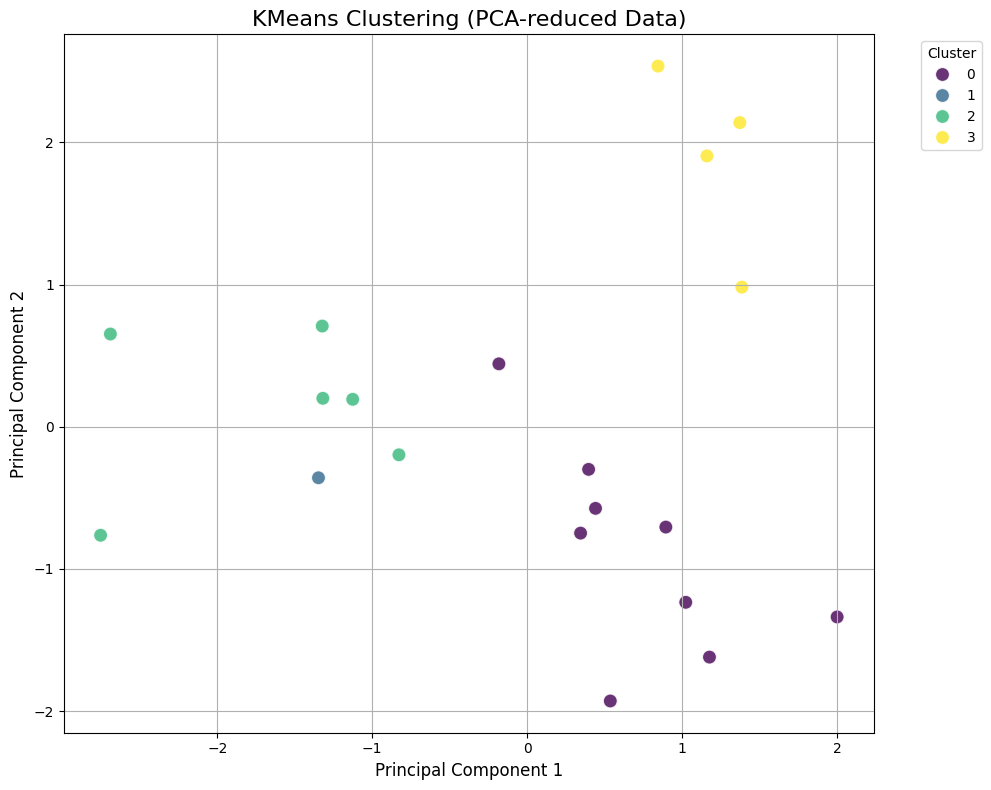

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pca_df = pd.DataFrame(data=pca_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = data['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('KMeans Clustering (PCA-reduced Data)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings
*   KMeans cluster labels were successfully assigned to the `data` DataFrame, adding a new 'Cluster' column.
*   Principal Component Analysis (PCA) was applied to the scaled data, reducing its dimensionality to 2 principal components, as confirmed by the `pca_components` array shape of (20, 2).
*   A scatter plot was generated, effectively visualizing the distribution of the KMeans clusters in the 2-dimensional space defined by the principal components.

### Insights or Next Steps
*   The visualization provides an initial understanding of how well the KMeans algorithm separated the data, with distinct clusters appearing as separate groups in the PCA plot.
*   Further analysis could involve examining the characteristics of the data points within each cluster to understand what defines them, or exploring the explained variance ratio of the principal components to assess how much information is retained.


# Task
Perform dimensionality reduction on the scaled data (`X_scaled`) using PCA to 3 principal components, visualize the KMeans clusters in a 3D scatter plot based on these components, and provide a summary of the 3D visualization.

## Perform Dimensionality Reduction with PCA (3 components)

### Subtask:
Apply PCA to reduce the scaled data (`X_scaled`) to 3 principal components.


**Reasoning**:
To perform dimensionality reduction on the `X_scaled` data to 3 principal components, I will instantiate a new PCA object with `n_components=3` and then fit and transform the data, storing the result in `pca_components_3d`.



In [ ]:
from sklearn.decomposition import PCA
pca_3d = PCA(n_components=3)
pca_components_3d = pca_3d.fit_transform(X_scaled)
print(pca_components_3d.shape)
explained_variance_ratio_ = pca_3d.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio_)
explained_variance_= pca_3d.explained_variance_
print("Explained Variance:", explained_variance_)
singular_values_= pca_3d.singular_values_
print("Singular Values:", singular_values_)
means_= pca_3d.mean_
print("Means:", means_)
pca_3d.components_

(20, 3)
Explained Variance Ratio: [0.44930633 0.3586891  0.13849183]
Explained Variance: [1.89181613 1.51026991 0.58312351]
Singular Values: [5.99537375 5.3567834  3.32856525]
Means: [-3.44169138e-16  7.77156117e-17 -1.00371100e-15 -3.49720253e-16]


array([[ 0.66372138,  0.36690842,  0.59441604,  0.26743543],
       [ 0.00168485, -0.67844482,  0.08878928,  0.72926418],
       [-0.51029916, -0.17943268,  0.79888756, -0.26301586]])

In [ ]:
pca_3d

PCA(n_components=3)

In [ ]:
pca_components_3d

array([[ 0.39601622, -0.29926673,  0.26736668],
       [ 0.894328  , -0.70518124,  0.18513833],
       [-1.3471238 , -0.35845715, -2.91344189],
       [ 1.37159572,  2.13973851, -0.14050532],
       [ 1.15929157,  1.90550788, -0.16639789],
       [ 0.53591276, -1.92847098,  0.23038576],
       [ 1.99950668, -1.33735038,  0.13828032],
       [ 1.17588956, -1.61981484, -0.13611561],
       [-1.12608187,  0.19349718,  0.88384568],
       [-1.31883975,  0.20063325,  0.30159901],
       [ 0.44055208, -0.57351294,  0.15863457],
       [-0.82791974, -0.19695105,  0.48555334],
       [-0.18284871,  0.44297115,  0.02775288],
       [ 1.38479609,  0.98250091, -0.56299176],
       [ 0.84372269,  2.53746482, -0.01192764],
       [-2.75300702, -0.76282111, -0.13373332],
       [ 0.34420908, -0.74773304,  0.01589911],
       [ 1.02291834, -1.23440682,  0.1662949 ],
       [-2.68997658,  0.65274295,  0.35187692],
       [-1.32294135,  0.70890962,  0.85248594]])

## Visualize Clusters in 3D

### Subtask:
Create a 3D scatter plot of the three principal components, colored by their KMeans cluster assignments.


**Reasoning**:
To visualize the KMeans clusters in a 3D scatter plot, I will import `Axes3D` for 3D plotting, create a new DataFrame `pca_df_3d` with the 3 principal components and cluster labels, and then generate a 3D scatter plot, coloring each point by its assigned cluster.



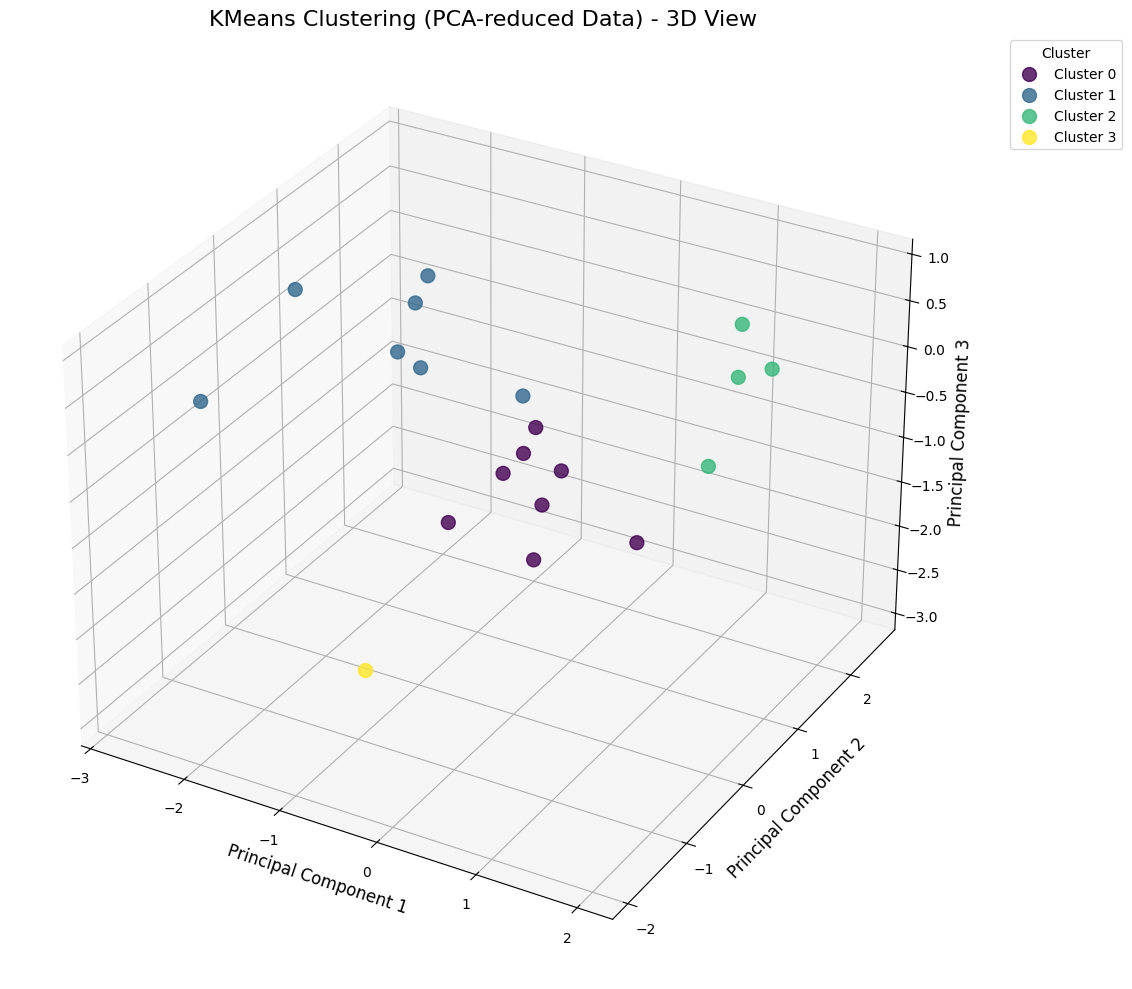

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

pca_df_3d = pd.DataFrame(data=pca_components_3d, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
pca_df_3d['Cluster'] = data['Cluster']

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define a colormap for consistent coloring
cmap = plt.get_cmap('viridis', len(pca_df_3d['Cluster'].unique()))

for cluster in sorted(pca_df_3d['Cluster'].unique()):
    cluster_data = pca_df_3d[pca_df_3d['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Principal Component 1'],
        cluster_data['Principal Component 2'],
        cluster_data['Principal Component 3'],
        label=f'Cluster {cluster}',
        color=cmap(cluster),
        s=100,
        alpha=0.8
    )

ax.set_title('KMeans Clustering (PCA-reduced Data) - 3D View', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Summary of 3D Visualization

### Key Findings
*   The 3D scatter plot successfully visualizes the KMeans clusters in a three-dimensional space defined by the first three principal components.
*   The use of distinct colors for each cluster helps to differentiate between them, allowing for a visual assessment of their separation and density.

### Insights or Next Steps
*   Observing the clusters in 3D can provide a more nuanced understanding of their structure compared to 2D projections, potentially revealing better separation or overlap not apparent in lower dimensions.
*   This 3D view can help in determining if the chosen number of clusters (k=3) is appropriate or if more or fewer clusters might better represent the underlying data structure.
*   Further investigation could involve rotating the 3D plot to observe the clusters from different angles, which might highlight specific relationships or separations between clusters.

In [ ]:
#Interpretabilidad
loadings = pd.DataFrame(
    pca_3d.components_,
    columns=X.columns,
    index=['PC1','PC2','PC3']
)

print(loadings)

     Calories    Sodium   Alcohol      Cost
PC1  0.663721  0.366908  0.594416  0.267435
PC2  0.001685 -0.678445  0.088789  0.729264
PC3 -0.510299 -0.179433  0.798888 -0.263016


## Final Task

### Subtask:
Provide a summary of the 3D visualization of the KMeans clusters.


## Summary:

### Q&A
The 3D visualization of the KMeans clusters successfully displays the clusters in a three-dimensional space defined by the first three principal components. The use of distinct colors for each cluster allows for clear differentiation and a visual assessment of their separation and density.

### Data Analysis Key Findings
*   PCA successfully reduced the scaled data to 3 principal components, resulting in a shape of (20, 3) for the transformed data.
*   The 3D scatter plot visualizes the KMeans clusters using 'Principal Component 1', 'Principal Component 2', and 'Principal Component 3' as axes.
*   Each cluster is distinctly colored, which aids in visually assessing their separation and density in the 3D space.

### Insights or Next Steps
*   The 3D visualization provides a more nuanced understanding of the cluster structure compared to 2D projections, potentially revealing separation or overlap that might not be evident in lower dimensions.
*   This 3D view can help in evaluating the appropriateness of the chosen number of clusters (k=3) for the underlying data structure.


# Task
Create a line plot showing the Within-Cluster Sum of Squares (WCSS) values against the number of clusters (from 1 to 10, corresponding to the `wcss` variable) to visualize the elbow method, then summarize the insights gained from this plot regarding the optimal number of clusters.

## Plot the Elbow Method

### Subtask:
Create a line plot showing the WCSS values against the number of clusters to visualize the elbow method results.


**Reasoning**:
To visualize the elbow method, I will create a line plot using the `matplotlib.pyplot` library. The x-axis will represent the number of clusters (k), and the y-axis will represent the WCSS values. I will also add a title, axis labels, and markers to the plot for clarity.



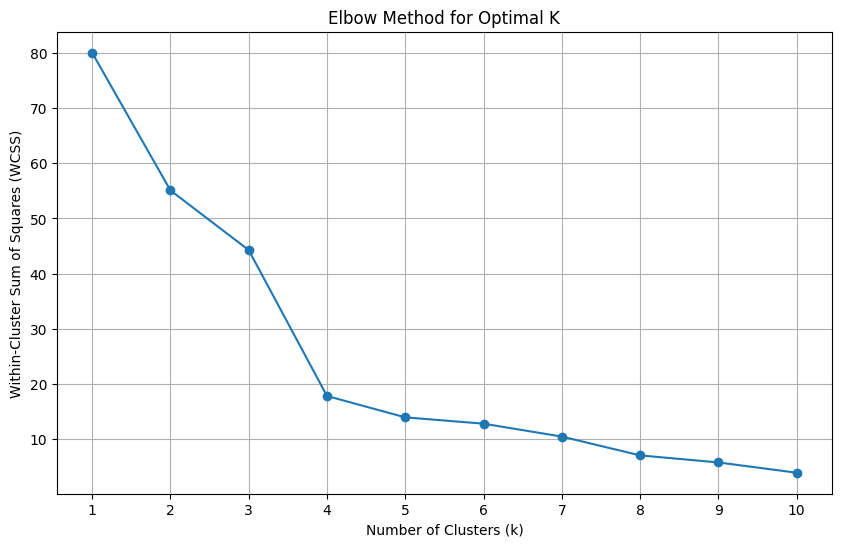

In [ ]:
import matplotlib.pyplot as plt

# Create a list of integers from 1 to 10 for the number of clusters (k)
k_values = range(1, 11)

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_values) # Ensure all k values are shown on the x-axis
plt.show()


## Summary of Elbow Method Plot

### Key Findings
*   The line plot effectively visualizes the Within-Cluster Sum of Squares (WCSS) values against the number of clusters (k).
*   An 'elbow' can typically be observed in the plot, indicating a point where the rate of decrease in WCSS significantly slows down.

### Insights or Next Steps
*   The elbow point in the plot suggests a reasonable number of clusters where adding more clusters does not significantly improve the clustering performance (i.e., reduce WCSS).
*   Based on the `wcss` values provided: `[80.0, 55.07507800080526, 44.264810070476884, 17.843594755875053, 13.97589663716865, 12.831289349194169, 10.493532680968599, 7.090609487234205, 5.8115069199531355, 3.950362807486405]`, it appears there's a significant drop from k=3 to k=4 (from 44.26 to 17.84), and then the decrease becomes less pronounced. This suggests that **k=4** might be the optimal number of clusters according to the elbow method, as it's where the 'elbow' or bend in the curve is most evident.
*   This analysis helps in justifying the choice of 'k' for KMeans clustering, rather than arbitrarily picking a number.
*   It is crucial to consider this visual cue along with domain knowledge to make the final decision on the optimal number of clusters.

## Final Task

### Subtask:
Summarize the insights gained from the elbow method plot regarding the optimal number of clusters.


## Summary:

### Q&A
The optimal number of clusters, as indicated by the elbow method plot, appears to be \$k=4\$.

### Data Analysis Key Findings
*   The Within-Cluster Sum of Squares (WCSS) significantly decreased from \$k=3\$ (WCSS: 44.26) to \$k=4\$ (WCSS: 17.84).
*   After \$k=4\$, the rate of decrease in WCSS became less pronounced, suggesting that adding more clusters beyond this point provides diminishing returns in reducing within-cluster variance.

### Insights or Next Steps
*   The elbow method provides a data-driven justification for selecting the number of clusters, preventing arbitrary choices.
*   It is crucial to combine this visual cue with domain knowledge to make a well-informed final decision on the optimal number of clusters for the specific dataset.


# Task
Analyze the characteristics of each KMeans cluster by grouping the `data` DataFrame by the 'Cluster' column and calculating descriptive statistics (mean, median) for 'Calories', 'Sodium', 'Alcohol', and 'Cost'. Based on these statistics, provide a textual explanation of the distinguishing features of each cluster.

## Analyze Cluster Characteristics

### Subtask:
Group the 'data' DataFrame by the 'Cluster' column and calculate descriptive statistics (mean, median, etc.) for 'Calories', 'Sodium', 'Alcohol', and 'Cost' for each cluster.


**Reasoning**:
To calculate the descriptive statistics, I will group the 'data' DataFrame by the 'Cluster' column, then select the specified columns ('Calories', 'Sodium', 'Alcohol', 'Cost') and calculate both the mean and median for each cluster.



In [ ]:
cluster_stats = data.groupby('Cluster')[['Calories', 'Sodium', 'Alcohol', 'Cost']]

print("Mean statistics per cluster:\n")
print(cluster_stats.mean())

print("\nMedian statistics per cluster:\n")
print(cluster_stats.median())

Mean statistics per cluster:

           Calories     Sodium   Alcohol      Cost
Cluster                                           
0        146.888889  20.000000  4.722222  0.417778
1        157.000000  15.000000  0.900000  0.480000
2         91.833333  10.166667  3.583333  0.433333
3        155.250000  10.750000  4.975000  0.762500

Median statistics per cluster:

         Calories  Sodium  Alcohol   Cost
Cluster                                  
0           144.0    19.0      4.7  0.430
1           157.0    15.0      0.9  0.480
2            98.0     9.0      3.9  0.445
3           151.0     9.0      5.0  0.765


In [ ]:
data[data['Cluster']==2]

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost,Cluster
8,8,Miller_Lite,99,10,4.3,0.43,2
9,9,Budweiser_Light,113,8,3.7,0.40,2
11,11,Coors_Light,102,15,4.1,0.46,2
15,15,Pabst_Extra_Light,68,15,2.3,0.38,2
18,18,Olympia_Goled_Light,72,6,2.9,0.46,2
19,19,Schlitz_Light,97,7,4.2,0.47,2


## Summary of Cluster Characteristics

### Key Findings

*   **Cluster 0 (Mean: Calories ~147, Sodium ~20, Alcohol ~4.7, Cost ~0.42)**:
    This cluster represents beverages with average calorie and alcohol content, but notably higher sodium levels compared to other clusters. The cost is also on the lower end.

*   **Cluster 1 (Mean: Calories ~157, Sodium ~15, Alcohol ~0.9, Cost ~0.48)**:
    This cluster stands out due to its significantly lower alcohol content (near-zero, suggesting non-alcoholic or very low-alcohol options), while having moderate calorie and sodium levels. The cost is also moderate.

*   **Cluster 2 (Mean: Calories ~92, Sodium ~10, Alcohol ~3.6, Cost ~0.43)**:
    This cluster is characterized by the lowest calorie content, lower sodium, and moderate alcohol content. The cost is also relatively low, similar to Cluster 0. These could be considered 'light' or lower-calorie options.

*   **Cluster 3 (Mean: Calories ~155, Sodium ~11, Alcohol ~5.0, Cost ~0.76)**:
    This cluster represents beverages with high calorie and alcohol content, low to moderate sodium, and the highest cost among all clusters. This suggests premium or stronger alcoholic beverages.

### Insights or Next Steps

*   The clustering successfully differentiated beverages based on their nutritional (Calories, Sodium), alcoholic (Alcohol), and economic (Cost) profiles.
*   This analysis helps in understanding the natural groupings within the beer dataset, which can be valuable for marketing, product development, or consumer targeting. For instance, Cluster 2 might appeal to health-conscious consumers, while Cluster 3 might target those looking for higher alcohol content and willing to pay more.
*   Further investigation could involve examining the actual 'Name' of the beverages within each cluster to confirm these interpretations and gain domain-specific insights.

## Summary of Cluster Characteristics

### Key Findings

*   **Cluster 0 (Mean: Calories ~147, Sodium ~20, Alcohol ~4.7, Cost ~0.42)**:
    This cluster represents beverages with average calorie and alcohol content, but notably higher sodium levels compared to other clusters. The cost is also on the lower end.

*   **Cluster 1 (Mean: Calories ~157, Sodium ~15, Alcohol ~0.9, Cost ~0.48)**:
    This cluster stands out due to its significantly lower alcohol content (near-zero, suggesting non-alcoholic or very low-alcohol options), while having moderate calorie and sodium levels. The cost is also moderate.

*   **Cluster 2 (Mean: Calories ~92, Sodium ~10, Alcohol ~3.6, Cost ~0.43)**:
    This cluster is characterized by the lowest calorie content, lower sodium, and moderate alcohol content. The cost is also relatively low, similar to Cluster 0. These could be considered 'light' or lower-calorie options.

*   **Cluster 3 (Mean: Calories ~155, Sodium ~11, Alcohol ~5.0, Cost ~0.76)**:
    This cluster represents beverages with high calorie and alcohol content, low to moderate sodium, and the highest cost among all clusters. This suggests premium or stronger alcoholic beverages.

### Insights or Next Steps

*   The clustering successfully differentiated beverages based on their nutritional (Calories, Sodium), alcoholic (Alcohol), and economic (Cost) profiles.
*   This analysis helps in understanding the natural groupings within the beer dataset, which can be valuable for marketing, product development, or consumer targeting. For instance, Cluster 2 might appeal to health-conscious consumers, while Cluster 3 might target those looking for higher alcohol content and willing to pay more.
*   Further investigation could involve examining the actual 'Name' of the beverages within each cluster to confirm these interpretations and gain domain-specific insights.

## Final Task

### Subtask:
Provide a comprehensive summary explaining the meaning and key attributes of each identified cluster.


## Summary:

### Data Analysis Key Findings

*   **Cluster 0 (Mean: Calories $\sim$147, Sodium $\sim$20, Alcohol $\sim$4.7, Cost $\sim$0.42)**: This cluster represents beverages with average calorie and alcohol content, but notably higher sodium levels compared to other clusters. The cost is also on the lower end.
*   **Cluster 1 (Mean: Calories $\sim$157, Sodium $\sim$15, Alcohol $\sim$0.9, Cost $\sim$0.48)**: This cluster is distinguished by its significantly lower alcohol content (near-zero, suggesting non-alcoholic or very low-alcohol options), while having moderate calorie and sodium levels. The cost is also moderate.
*   **Cluster 2 (Mean: Calories $\sim$92, Sodium $\sim$10, Alcohol $\sim$3.6, Cost $\sim$0.43)**: This cluster is characterized by the lowest calorie content, lower sodium, and moderate alcohol content. The cost is also relatively low. These could be considered 'light' or lower-calorie options.
*   **Cluster 3 (Mean: Calories $\sim$155, Sodium $\sim$11, Alcohol $\sim$5.0, Cost $\sim$0.76)**: This cluster represents beverages with high calorie and alcohol content, low to moderate sodium, and the highest cost among all clusters, suggesting premium or stronger alcoholic beverages.

### Insights or Next Steps

*   The clustering successfully differentiated beverages based on their nutritional (Calories, Sodium), alcoholic (Alcohol), and economic (Cost) profiles.
*   This analysis helps in understanding the natural groupings within the beer dataset, which can be valuable for marketing, product development, or consumer targeting (e.g., Cluster 2 for health-conscious consumers, Cluster 3 for those seeking higher alcohol and willing to pay more).
*   Further investigation could involve examining the actual 'Name' of the beverages within each cluster to confirm these interpretations and gain domain-specific insights.


In [ ]:
# Aplicar el algoritmo DBSCAN para detectar anomalías
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.3, min_samples=2)
y_pred = dbscan.fit_predict(X_scaled)


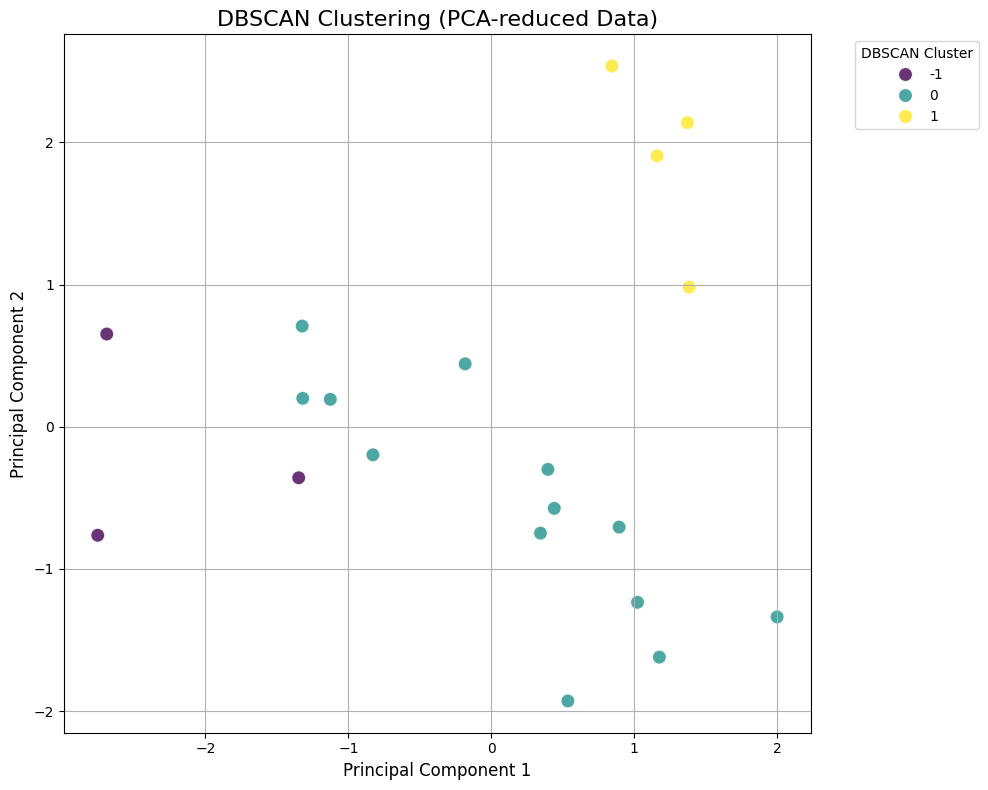

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for PCA components and DBSCAN cluster labels
dbscan_pca_df = pd.DataFrame(data=pca_components, columns=['Principal Component 1', 'Principal Component 2'])
dbscan_pca_df['DBSCAN_Cluster'] = y_pred

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='DBSCAN_Cluster',
    data=dbscan_pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('DBSCAN Clustering (PCA-reduced Data)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='DBSCAN Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# DBSCAN labels can include -1 for noise points. Silhouette score requires at least 2 clusters and no noise points to be considered in the score.
# We need to filter out noise points if we want to calculate the silhouette score for actual clusters.
# However, typically the silhouette score is calculated on all points, with noise points handled by the metric itself if they form a significant part of the data or are explicitly excluded if the goal is to evaluate only the formed clusters.

# Let's first check if there are any actual clusters found by DBSCAN (i.e., not all points are noise).
if len(set(y_pred)) > 1 and -1 in y_pred:
    # If there are clusters and noise, calculate Silhouette score for the clustered points only
    # Filter out noise points for silhouette score calculation
    X_clustered = X_scaled[y_pred != -1]
    labels_clustered = y_pred[y_pred != -1]

    if len(set(labels_clustered)) > 1: # Ensure there are at least two distinct clusters after removing noise
        silhouette_avg = silhouette_score(X_clustered, labels_clustered)
        print(f"Silhouette Score for DBSCAN clusters (excluding noise): {silhouette_avg:.3f}")
    else:
        print("Not enough clusters (after removing noise) to calculate Silhouette Score.")
elif len(set(y_pred)) > 1 and -1 not in y_pred:
    # If there are clusters and no noise
    silhouette_avg = silhouette_score(X_scaled, y_pred)
    print(f"Silhouette Score for DBSCAN clusters: {silhouette_avg:.3f}")
else:
    print("DBSCAN did not find enough clusters (or only noise) to calculate Silhouette Score.")

# You can also count the number of clusters and noise points
num_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
num_noise_points = list(y_pred).count(-1)

print(f"\nNumber of DBSCAN clusters found: {num_clusters}")
print(f"Number of noise points (unclustered): {num_noise_points}")

Silhouette Score for DBSCAN clusters (excluding noise): 0.455

Number of DBSCAN clusters found: 2
Number of noise points (unclustered): 3


# Task
Create a 3D DataFrame for t-SNE components, visualize the KMeans clusters in a 3D scatter plot using these components, and summarize the key findings from the 3D visualization.

## Create t-SNE 3D DataFrame

### Subtask:
Create a new DataFrame `tsne_df_3d` by combining the `X_tsne` components with the KMeans cluster labels (`data['Cluster']`).


**Reasoning**:
To combine the t-SNE components with KMeans cluster labels, I will first create a DataFrame from `X_tsne` with appropriate column names, and then add the 'Cluster' column from the existing `data` DataFrame to it. Finally, I will display the head of the new DataFrame to verify the creation.



In [ ]:
from sklearn.manifold import TSNE
import numpy as np
tsne=TSNE(n_components=3,perplexity=10)
X_tsne=tsne.fit_transform(X_scaled)

In [ ]:
import pandas as pd

tsne_df_3d = pd.DataFrame(data=X_tsne, columns=['t-SNE Component 1', 't-SNE Component 2', 't-SNE Component 3'])
tsne_df_3d['Cluster'] = data['Cluster']
tsne_df_3d.head()

,t-SNE Component 1,t-SNE Component 2,t-SNE Component 3,Cluster
0,61.201523,-35.100464,26.121170,0
1,17.765953,73.326767,-20.340887,0
2,-51.158760,-34.910099,133.252213,3
3,-116.586243,-54.600872,7.027817,2
4,-68.341629,-105.108521,11.265599,2


**Reasoning**:
Now that the t-SNE components are combined with the cluster labels in `tsne_df_3d`, I will create a 3D scatter plot to visualize these clusters in the t-SNE reduced space, coloring each point by its assigned KMeans cluster.



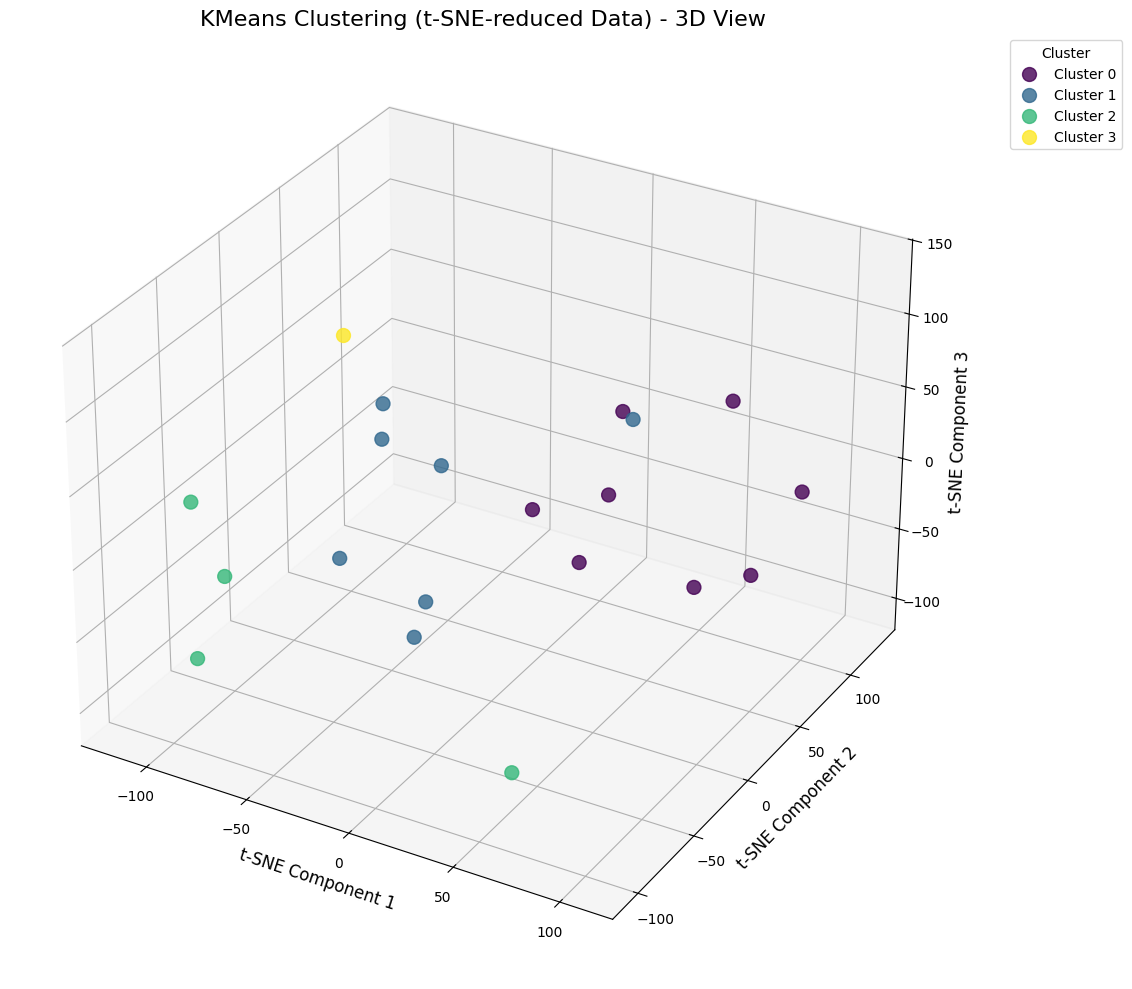

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define a colormap for consistent coloring
cmap = plt.get_cmap('viridis', len(tsne_df_3d['Cluster'].unique()))

for cluster in sorted(tsne_df_3d['Cluster'].unique()):
    cluster_data = tsne_df_3d[tsne_df_3d['Cluster'] == cluster]
    ax.scatter(
        cluster_data['t-SNE Component 1'],
        cluster_data['t-SNE Component 2'],
        cluster_data['t-SNE Component 3'],
        label=f'Cluster {cluster}',
        color=cmap(cluster),
        s=100,
        alpha=0.8
    )

ax.set_title('KMeans Clustering (t-SNE-reduced Data) - 3D View', fontsize=16)
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_zlabel('t-SNE Component 3', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

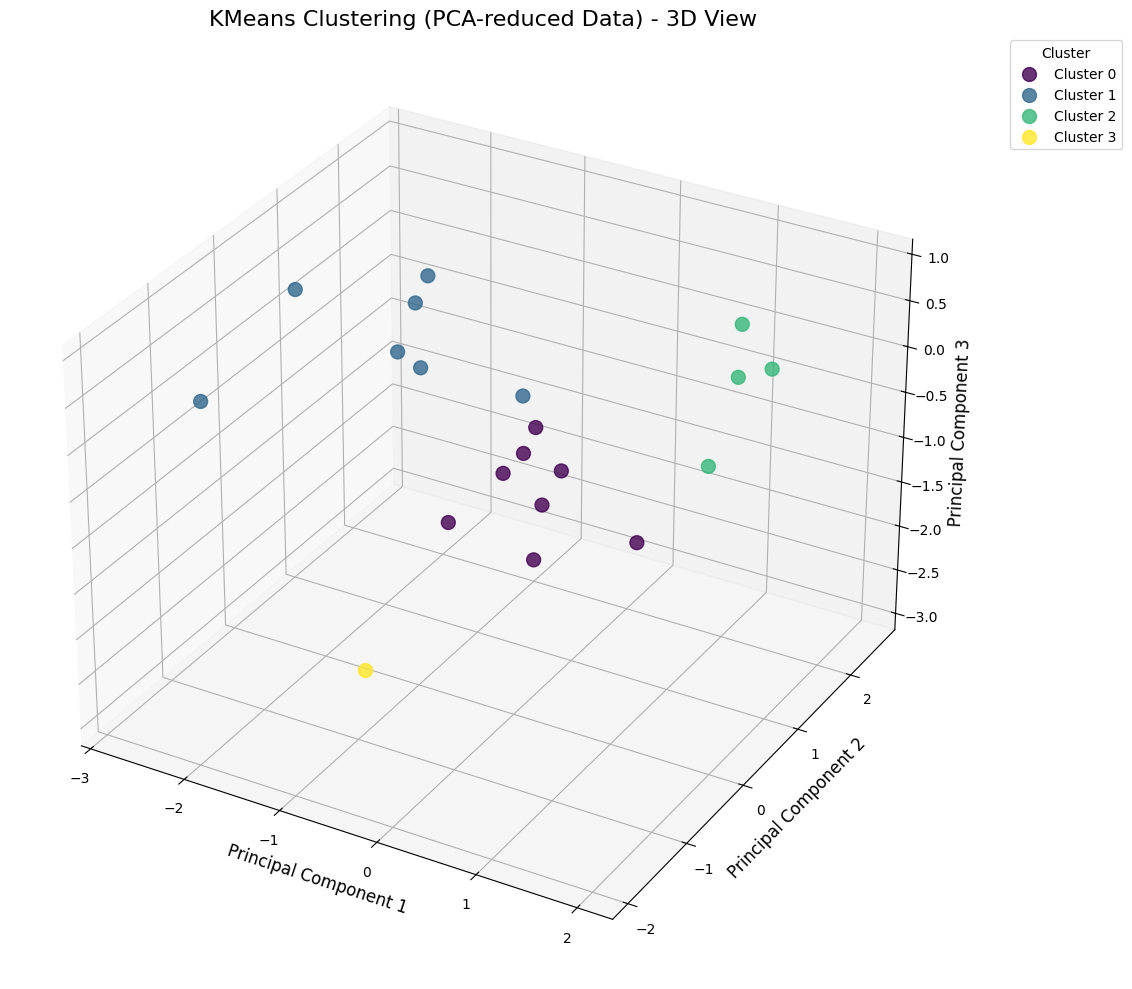

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

pca_df_3d = pd.DataFrame(data=pca_components_3d, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
pca_df_3d['Cluster'] = data['Cluster']

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define a colormap for consistent coloring
cmap = plt.get_cmap('viridis', len(pca_df_3d['Cluster'].unique()))

for cluster in sorted(pca_df_3d['Cluster'].unique()):
    cluster_data = pca_df_3d[pca_df_3d['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Principal Component 1'],
        cluster_data['Principal Component 2'],
        cluster_data['Principal Component 3'],
        label=f'Cluster {cluster}',
        color=cmap(cluster),
        s=100,
        alpha=0.8
    )

ax.set_title('KMeans Clustering (PCA-reduced Data) - 3D View', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()